<img src="https://assets-datascientest.s3-eu-west-1.amazonaws.com/train/logo_datascientest.png" style="height:150px">

<hr style="border-width:2px;border-color:#75DFC1">

<center><h1> ORT : Machine Learning </h1></center>

<hr style="border-width:2px;border-color:#75DFC1">


> Notre objectif dans cet exercice est de proposer une solution plus avancée à notre commanditaire.
Nous souhaitons prédire la couverture corallienne d’un **récif** à l’année *t* à partir de l’ensemble des informations disponibles à l’année 
*t−1* pour ce même **récif**.
>
> Notre ambition est double :
> 
- obtenir des prédictions précises,
- mais aussi être capables d’expliquer les résultats produits par notre modèle.

> En d’autres termes, nous voulons **analyser l’impact de certaines variables exogènes**, comme les perturbations environnementales ou le fait qu’un récif se situe dans une zone protégée, sur la prédiction finale.
>
> Pour répondre à cet objectif, nous adopterons une approche de **Machine Learning**. Plusieurs étapes seront nécessaires :
>
- traiter les **valeurs manquantes** et proposer une stratégie pertinente pour leur gestion ;
- **créer de nouvelles variables** intégrant l’information chronologique, afin de capturer le comportement passé de la couverture corallienne pour chaque récif ;
- **formater la table finale** dans un format adapté à une démarche de Machine Learning (nous discuterons également des avantages et des limites de ce choix) ;
- **entraîner** un modèle de Machine Learning ;
- **évaluer** les performances du modèle ;
- **interpréter** les résultats afin de comprendre les facteurs influençant les prédictions ;
- éventuellement **optimiser** le modèle pour améliorer ses performances.

> Nous commencerons par importer les données et remplacer les valeurs `-999` par des valeurs manquantes (NaN).

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/GBR_ltmp.csv')


df.replace({-999 : np.nan, "-999" : np.nan}, inplace = True)
df.isna().sum().sort_values(ascending = False)

HC_1             4037
HERB2            3527
DISTURBANCE      3377
COVER            3352
DISEASE          3347
D                3347
HC               3347
STORM            3347
COTS             3347
B                3347
BLEACHING        3347
S                3347
C                3337
HERB             1380
LAT                 0
A_SECTOR            0
REEF_NAME           0
REEF_ID             0
SHELF               0
TRANSECT_NO         0
REPORT_YEAR         0
SITE_NO             0
SITE_LON            0
LON                 0
SITE_LAT            0
AREA                0
CONNECTEDNESS       0
BENT_CLUST          0
CLUSTER             0
RST                 0
RSTY                0
iZONE               0
sZONE               0
PFp                 0
PFs                 0
PFt                 0
PFsum               0
dtype: int64

> Nous devons maintenant traiter les valeurs manquantes des variables `HC` et `HC_1`, qui décrivent la couverture corallienne respectivement à l’année *t* et à l’année *t-1*.
>
> Pour cela, nous choisissons d’utiliser une **interpolation linéaire**, qui permet d’estimer les valeurs manquantes de `HC` et `HC_1` en réalisant une interpolation entre les observations aux années *t-1* et *t+1*.
>
> Par la suite, nous visualiserons les résultats à l’aide de line plots, afin de comparer les variables interpolées avec les variables d’origine.

In [26]:
df['HC_b'] = (df
    .groupby(['REEF_NAME', 'TRANSECT_NO'])['HC']
    .transform(lambda x: x.interpolate(method='linear')))


df['HC_1_b'] = (df
    .groupby(['REEF_NAME', 'TRANSECT_NO'])['HC_1']
    .transform(lambda x: x.interpolate(method='linear')))

> Utilisons la **data visualisation** afin d’observer l’impact de notre choix d’interpolation sur l’ensemble des données.

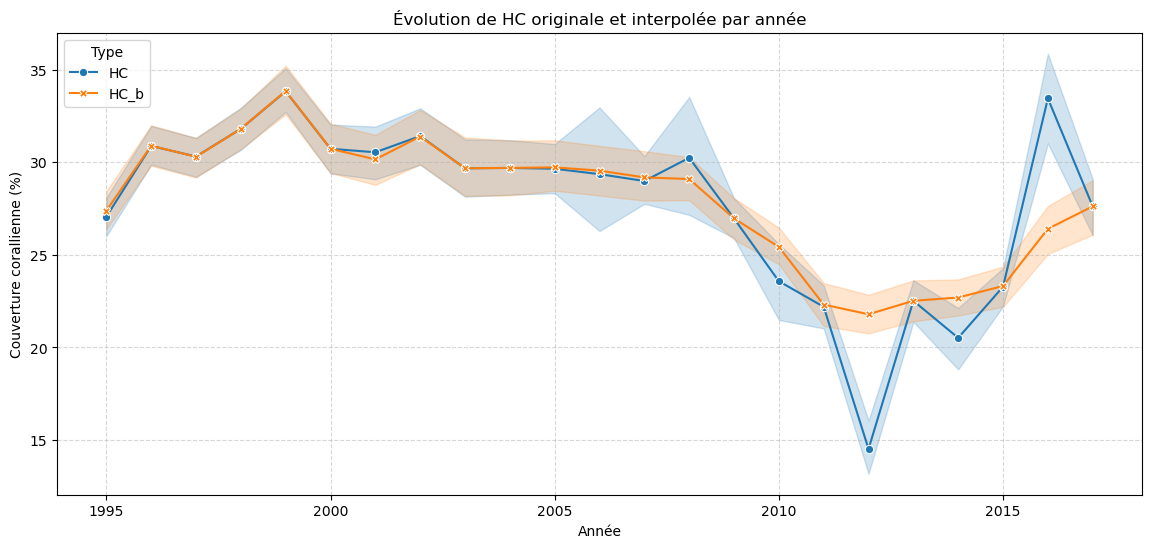

In [3]:
df_long = df.melt(
    id_vars=['REEF_NAME', 'REPORT_YEAR', 'SHELF'],
    value_vars=['HC', 'HC_b'],
    var_name='Type',
    value_name='HC_value'
)

plt.figure(figsize=(14,6))
sns.lineplot(
    data=df_long,
    x='REPORT_YEAR',
    y='HC_value',
    hue='Type',           
    style='Type',
    markers=True,
    dashes=False
)

plt.xlabel("Année")
plt.ylabel("Couverture corallienne (%)")
plt.title("Évolution de HC originale et interpolée par année")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

> Étudions l’impact de l’interpolation à l’échelle de chaque récif.

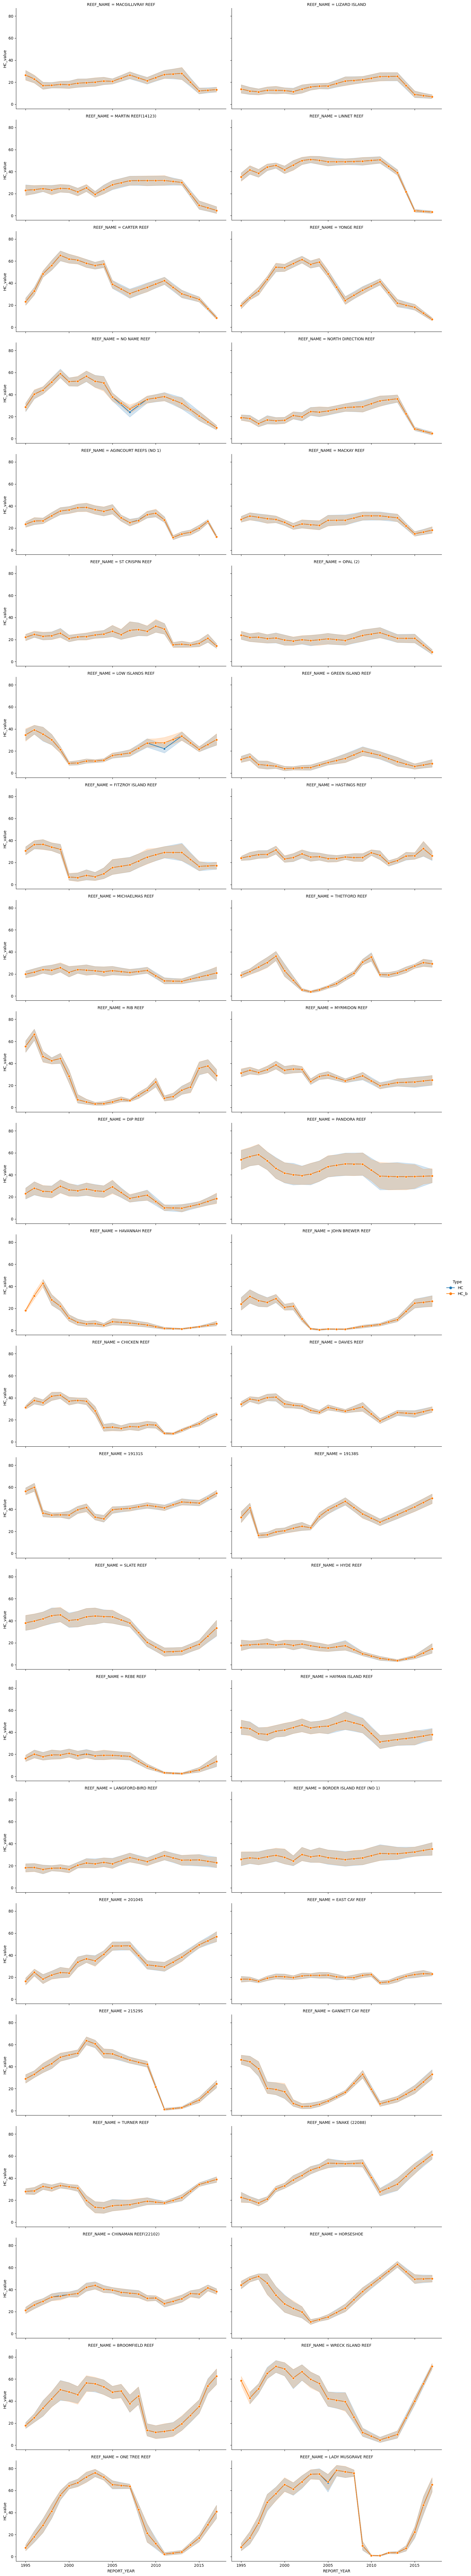

In [4]:
sns.relplot(
    data=df_long,
    x='REPORT_YEAR',
    y='HC_value',
    hue = 'Type',
    col='REEF_NAME',
    kind='line',
    col_wrap=2,     
    height=4,
    aspect=2,
    marker='o'
)

plt.show()

> Analysons également l’impact de l’interpolation à l’échelle des **plateaux coralliens**.

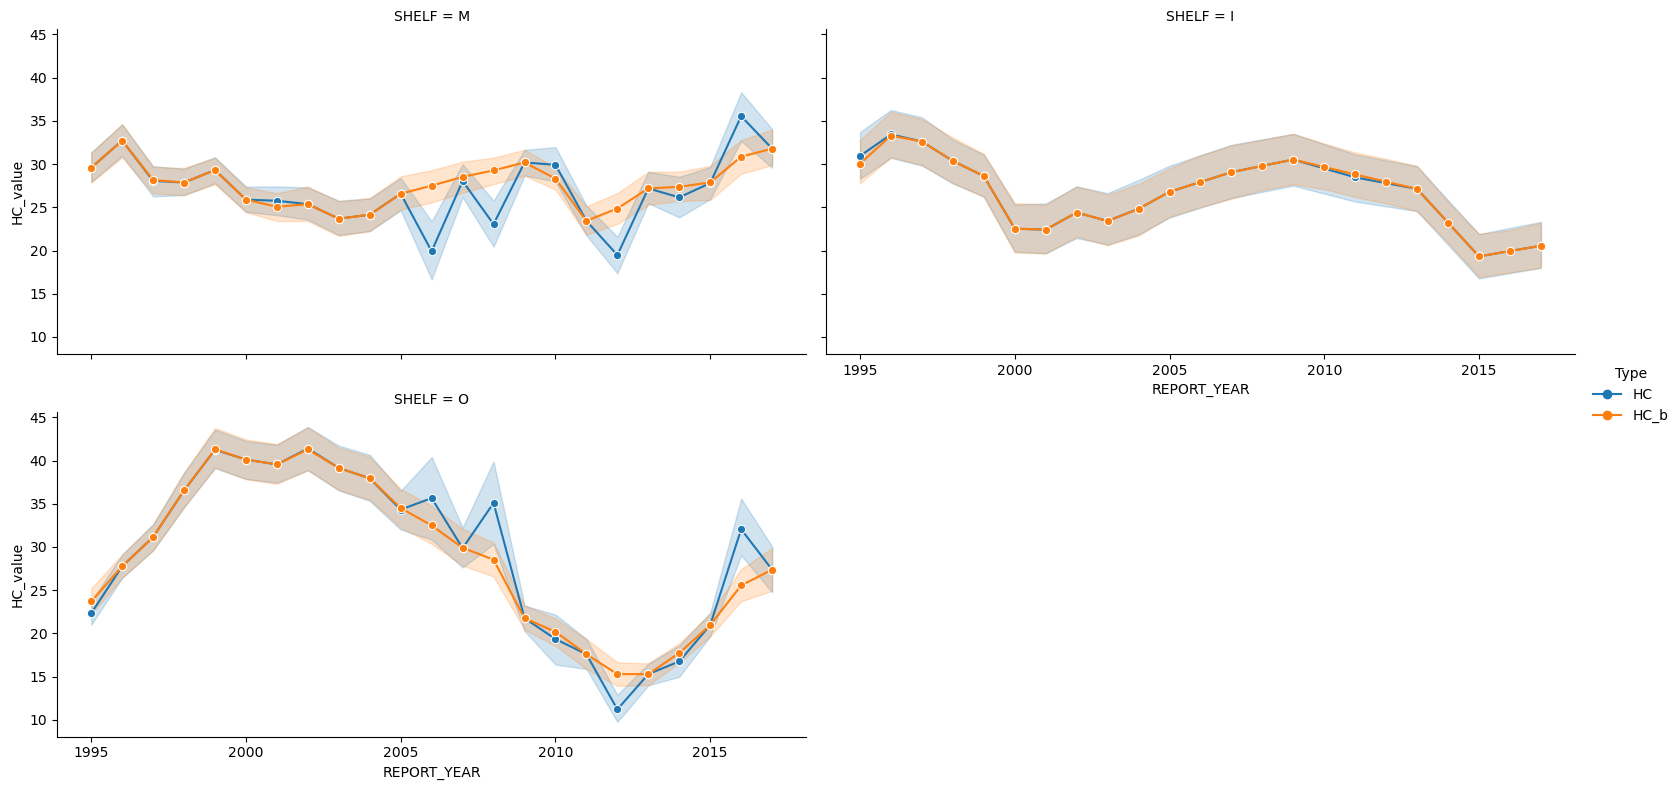

In [5]:
sns.relplot(
    data=df_long,
    x='REPORT_YEAR',
    y='HC_value',
    hue = 'Type',
    col='SHELF',
    kind='line',
    col_wrap=2,     
    height=4,
    aspect=2,
    marker='o'
)

plt.show()

> Créons maintenant une variable indiquant si le récif se situe dans une **zone protégée**, puis sélectionnons les variables que nous utiliserons pour la modélisation.

In [27]:
df["protected_area"] = ((df["iZONE"] == 1) | (df["sZONE"] == 1)).astype(int)

cols_to_keep = ['REPORT_YEAR', 'REEF_NAME', 'A_SECTOR', 
                'SITE_NO', 'TRANSECT_NO', 'HC_b', 'HC_1_b', 
                'CLUSTER', 'SHELF', 'DISTURBANCE', 'protected_area']

df_ml = df[cols_to_keep].copy()

> Nous pouvons maintenant traiter les valeurs manquantes.
> 
> À ce stade, nous décidons de supprimer les valeurs manquantes des variables `HC_b` et `HC_1_b`.
> 
> Pour la variable `DISTURBANCE`, nous remplacerons les NaN par la valeur de disturbance mesurée l’année précédente pour le même récif.

In [28]:
print("Valeurs manquantes avant traitement : ", df_ml.isna().sum()) 

df_ml['DISTURBANCE'] = (
    df_ml.sort_values(['REEF_NAME','REPORT_YEAR'])
      .groupby('REEF_NAME')['DISTURBANCE']
      .ffill()
)


df_ml['DISTURBANCE'] = df_ml['DISTURBANCE'].fillna(
    df_ml.groupby('REEF_NAME')['DISTURBANCE']
    .transform(lambda x: x.mode().iloc[0])
)

df_ml.isna().sum()

df = df_ml.dropna()

print("Valeurs manquantes après traitement : ", df_ml.isna().sum()) 

Valeurs manquantes avant traitement :  REPORT_YEAR          0
REEF_NAME            0
A_SECTOR             0
SITE_NO              0
TRANSECT_NO          0
HC_b                15
HC_1_b             245
CLUSTER              0
SHELF                0
DISTURBANCE       3377
protected_area       0
dtype: int64
Valeurs manquantes après traitement :  REPORT_YEAR         0
REEF_NAME           0
A_SECTOR            0
SITE_NO             0
TRANSECT_NO         0
HC_b               15
HC_1_b            245
CLUSTER             0
SHELF               0
DISTURBANCE         0
protected_area      0
dtype: int64


> Nous pouvons maintenant faire un travail de **feature engeneering** pour créer des nouvelles variables qui, par récif et année peuvent apporter li'nformation sur les années précédentes

In [29]:
df_ml['HC_2_b'] = df_ml.groupby(['REEF_NAME', 'SITE_NO', 'TRANSECT_NO'])['HC_b'].shift(2)

df_ml['HC_trend_2yrs'] = df_ml['HC_1_b'] - df_ml['HC_2_b']
df_ml['HC_increasing_2yrs'] = (df_ml['HC_trend_2yrs'] > 0).astype(int)


df_ml['HC_1_b_sd'] = df_ml.groupby(['REEF_NAME','REPORT_YEAR'])['HC_1_b'].transform('std')
df_ml['HC_2_b_sd'] = df_ml.groupby(['REEF_NAME','REPORT_YEAR'])['HC_2_b'].transform('std')

> Nous pouvons maintenant définir la table finale pour notre démarche.
> 
> Pour cela, **nous allons agréger les informations disponibles par transect et par site**afin d’obtenir une **valeur unique par récif**.
>
> La table finale comportera donc une **ligne par année et par récif**, avec la valeur moyenne de la couverture corallienne mesurée à travers les transects des différents sites.


In [30]:
reef_yearly = df_ml.groupby(['REEF_NAME', 'REPORT_YEAR']).agg({
    'HC_b': 'mean',
    'HC_1_b': 'mean',
    'HC_2_b': 'mean',
    'HC_trend_2yrs': 'mean',
    'HC_increasing_2yrs': 'mean',
    'HC_1_b_sd': 'mean',
    'HC_2_b_sd': 'mean',
    'CLUSTER': 'first',
    'SHELF': 'first',
    'DISTURBANCE': lambda x: x.mode()[0],
    'protected_area': 'first'
}).reset_index()

print(reef_yearly.shape)
print(reef_yearly.isna().sum())

(1058, 13)
REEF_NAME              0
REPORT_YEAR            0
HC_b                   0
HC_1_b                 0
HC_2_b                92
HC_trend_2yrs         92
HC_increasing_2yrs     0
HC_1_b_sd              0
HC_2_b_sd             92
CLUSTER                0
SHELF                  0
DISTURBANCE            0
protected_area         0
dtype: int64


> Nous supprimons les **valeurs manquantes**.

In [31]:
reef_yearly = reef_yearly.dropna(subset=[
    'HC_2_b',
    'HC_trend_2yrs', 'HC_2_b_sd',
])

> Nous pouvons maintenant créer notre variable cible.
> 
> Pour chaque récif, nous voulons prédire la valeur de la couverture corallienne pour l’année *t + 1* à partir des informations disponibles à *t*.
> 
> Nous travaillons encore avec un **lag** en créant une variable cible qui renseigne, pour chaque année, la valeur de la couverture corallienne pour l’année suivante.

In [32]:
reef_yearly = reef_yearly.sort_values(['REEF_NAME', 'REPORT_YEAR'])

reef_yearly['HC_target'] = (
    reef_yearly.groupby('REEF_NAME')['HC_b']
    .shift(-1)
)

> Nous séparons notre jeu d’entraînement du jeu de test en conservant la **structure chronologique**. Nous gardons les trois dernières années pour tester le modèle.

In [33]:
reef_yearly_train_viz = reef_yearly[reef_yearly['REPORT_YEAR'] <= 2013]
reef_yearly_test_viz = reef_yearly[reef_yearly['REPORT_YEAR'] >= 2014]

reef_yearly_train = reef_yearly_train_viz.drop('HC_b', axis = 1)
reef_yearly_test = reef_yearly_test_viz.drop('HC_b', axis = 1)

print(reef_yearly_train.shape)
print(reef_yearly_test.shape)
print(reef_yearly_train.isna().sum().sort_values(ascending = False)[:5])
print(reef_yearly_test.isna().sum().sort_values(ascending = False)[:5])

(782, 13)
(184, 13)
REEF_NAME        0
REPORT_YEAR      0
HC_1_b           0
HC_2_b           0
HC_trend_2yrs    0
dtype: int64
HC_target      46
REPORT_YEAR     0
HC_1_b          0
HC_2_b          0
REEF_NAME       0
dtype: int64


> Supprimons les valeurs manquantes sur la cible que nous venons de créer : étant donné que `shift()` décale la variable d’une valeur vers l’arrière, nous ne disposons plus des valeurs pour la dernière année.

In [34]:
reef_yearly_test.dropna(inplace = True)

> Nous pouvons maintenant préparer notre table conformément aux attentes de la librairie **Scikit-learn** : encodage des variables catégorielles et traitement des éventuelles valeurs manquantes.
>
> Nous devons ensuite séparer les **features** (variables explicatives ou indépendantes) de la **variable cible** (variable dépendante).

In [35]:
variables_cat = reef_yearly.select_dtypes(include = ['object']).columns
variables_cat

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

ohe.fit(reef_yearly_train[variables_cat])

train_encoded = ohe.transform(reef_yearly_train[variables_cat])
test_encoded = ohe.transform(reef_yearly_test[variables_cat])

encoded_cols = ohe.get_feature_names_out(variables_cat)

train_encoded_df = pd.DataFrame(train_encoded, columns=encoded_cols, index=reef_yearly_train.index)
test_encoded_df = pd.DataFrame(test_encoded, columns=encoded_cols, index=reef_yearly_test.index)

reef_yearly_train = pd.concat(
    [reef_yearly_train.drop(columns=variables_cat), train_encoded_df],
    axis=1
)

reef_yearly_test = pd.concat(
    [reef_yearly_test.drop(columns=variables_cat), test_encoded_df],
    axis=1
)


y_train = reef_yearly_train['HC_target']
reef_yearly_train = reef_yearly_train.drop(columns = ['HC_target'])

y_test = reef_yearly_test['HC_target']
reef_yearly_test = reef_yearly_test.drop(columns = ['HC_target'])

> Nous pouvons maintenant entraîner et évaluer notre modèle. 

MSE: 85.38, MAE: 6.87, R2 : 0.6380193575859635


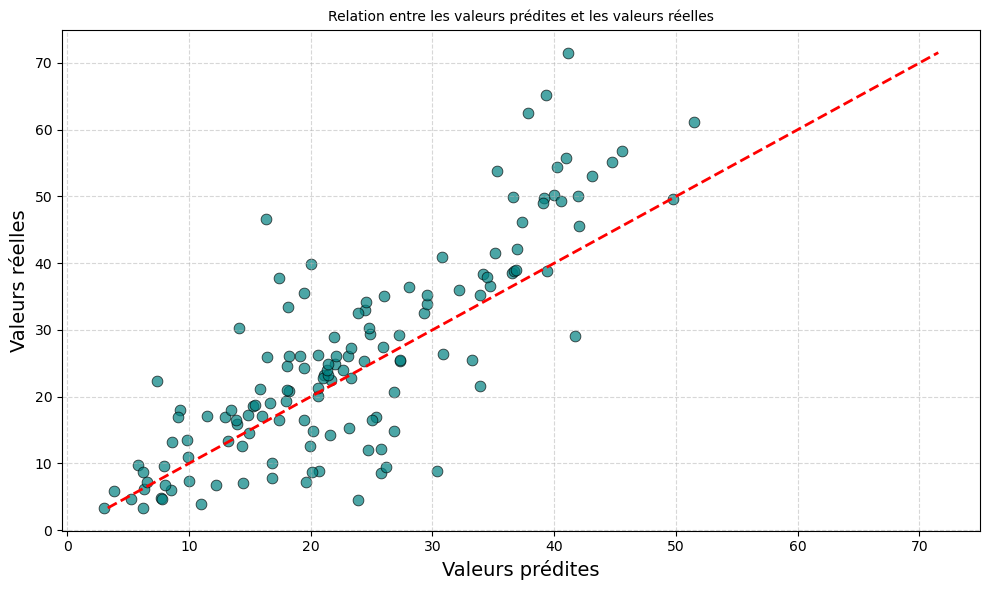

In [36]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.tree import plot_tree

rf = RandomForestRegressor(n_estimators=500, random_state=42) #bootstrap=False
rf.fit(reef_yearly_train, y_train)

y_pred = rf.predict(reef_yearly_test)

mse = mean_squared_error(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)

print(f"MSE: {mse:.2f}, MAE: {mae:.2f}, R2 : {rf.score(reef_yearly_test, y_test)}")


plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_pred, y=y_test, color='teal', s=60, alpha=0.7, edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.title("Relation entre les valeurs prédites et les valeurs réelles", fontsize=10)
plt.xlabel("Valeurs prédites", fontsize=14)
plt.ylabel("Valeurs réelles", fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

> Pour mieux comprendre la démarche, visualisons le premier arbre de notre forêt.
>
> Il est important de garder à l’esprit que notre modèle comporte 500 arbres fonctionnant en parallèle, et que cet arbre n’est qu’un exemple parmi tous les autres.

Nombre d'échantillons à la racine de l'arbre : 495


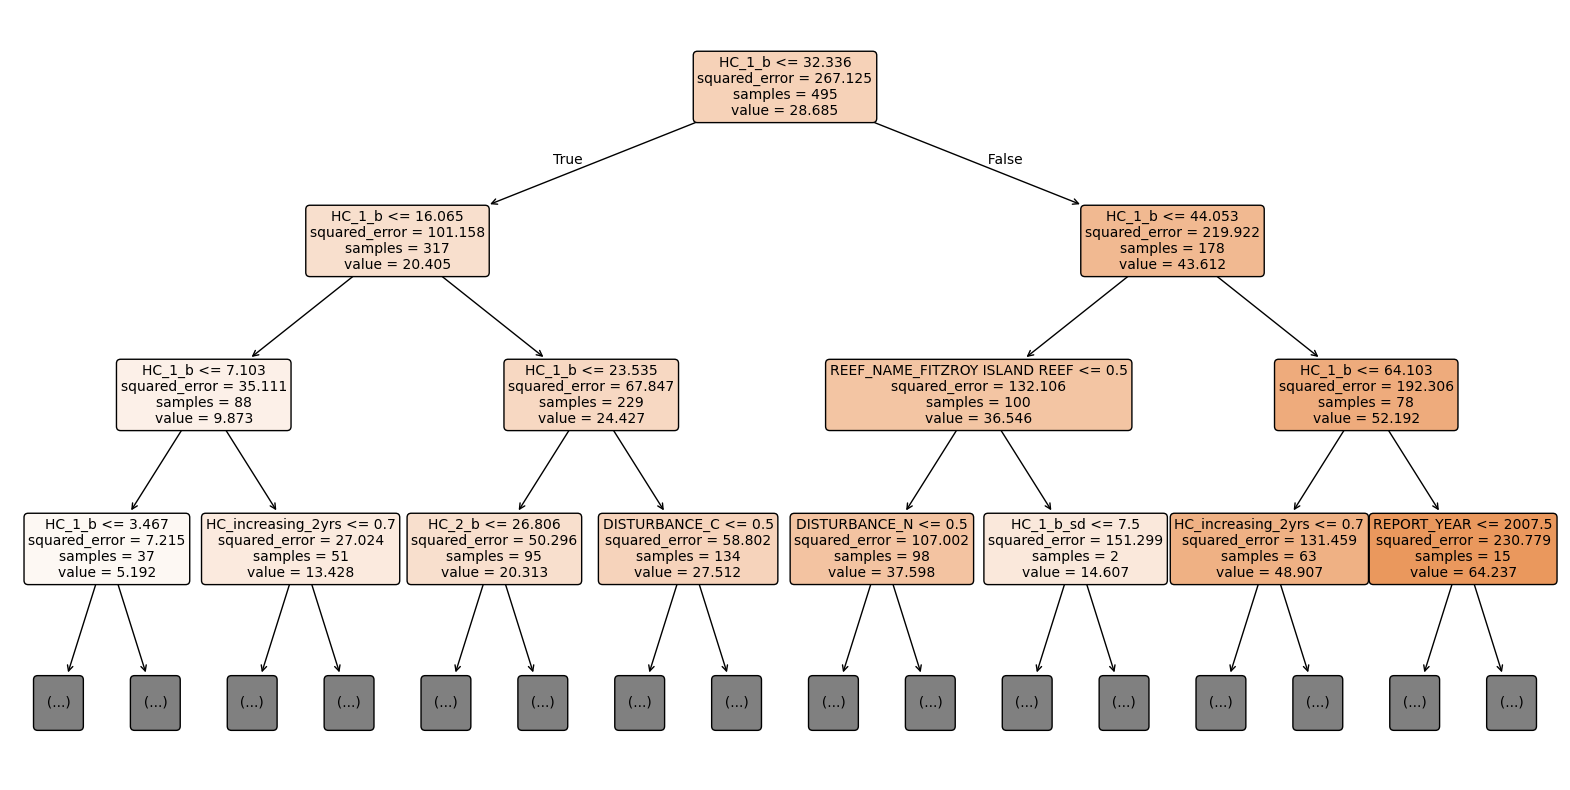

In [37]:
tree = rf.estimators_[0]
print("Nombre d'échantillons à la racine de l'arbre :", tree.tree_.n_node_samples[0])

tree = rf.estimators_[0]

plt.figure(figsize=(20,10))
plot_tree(
    tree,
    feature_names=reef_yearly_train.columns, 
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3
)
plt.show()

> Passons maintenant à la phase d’interprétation de nos résultats.
> 
> Nous allons visualiser le **comportement du modèle** et, par la suite, travailler sur son **interprétabilité**.
>
> En effet, nous devons pouvoir expliquer à notre client pour quelle raison le modèle prédit ce qu’il prédit, à la fois **globalement** et **localement** : sur l’ensemble de nos données, mais aussi pour un récif donné et une année donnée.
>
> Ici, nous examinons le récif `CHICKEN REEF`.

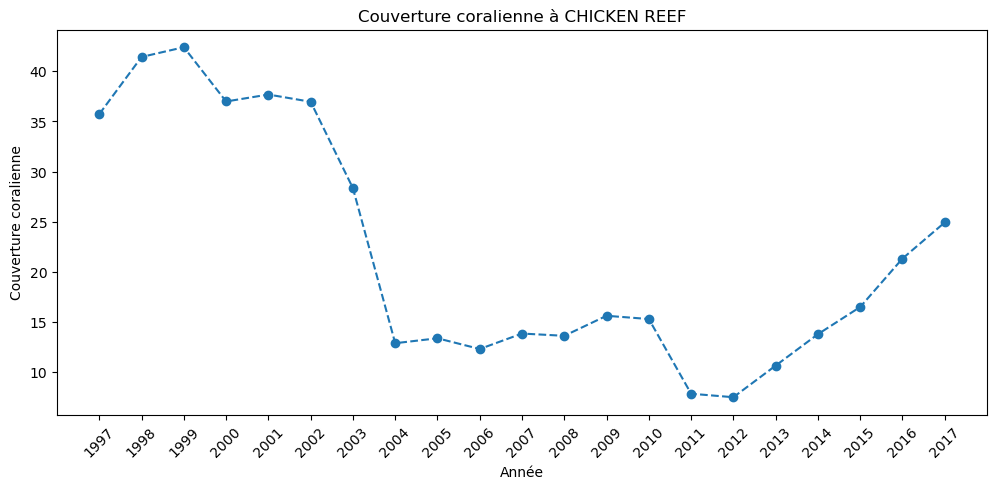

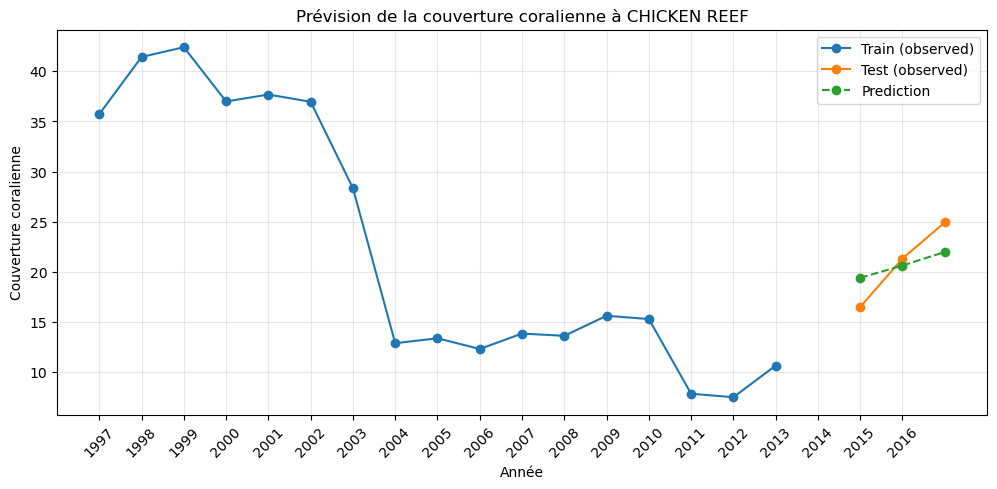

In [38]:
reef_yearly_test_viz = reef_yearly_test_viz.loc[reef_yearly_test.index].copy()
reef_yearly_test_viz['prediction'] = y_pred

train_reef = reef_yearly_train_viz[reef_yearly_train['REEF_NAME_CHICKEN REEF'] == 1]
test_reef  = reef_yearly_test_viz[reef_yearly_test['REEF_NAME_CHICKEN REEF'] == 1]

test_reef_plot = test_reef.copy()
test_reef_plot['REPORT_YEAR_target'] = test_reef_plot['REPORT_YEAR'] + 1

plt.figure(figsize = (12, 5))
plt.plot(reef_yearly.loc[reef_yearly['REEF_NAME'] == 'CHICKEN REEF']['REPORT_YEAR'], 
         reef_yearly.loc[reef_yearly['REEF_NAME'] == 'CHICKEN REEF']['HC_b'],  linestyle='--', marker='o') 
plt.xlabel("Année")
plt.ylabel("Couverture coralienne")
plt.title("Couverture coralienne à CHICKEN REEF")
plt.xticks(sorted(set(reef_yearly['REPORT_YEAR'])), rotation=45)


plt.figure(figsize=(12,5))

plt.plot(train_reef['REPORT_YEAR'], train_reef['HC_b'],
         label='Train (observed)', marker='o')

plt.plot(test_reef_plot['REPORT_YEAR_target'], y_test.loc[test_reef.index],
         label='Test (observed)', marker='o')

plt.plot(test_reef_plot['REPORT_YEAR_target'], test_reef_plot['prediction'],
         label='Prediction', linestyle='--', marker='o')

plt.xlabel("Année")
plt.ylabel("Couverture coralienne")
plt.title("Prévision de la couverture coralienne à CHICKEN REEF")

years = list(train_reef['REPORT_YEAR']) + list(test_reef['REPORT_YEAR'])
plt.xticks(sorted(set(years)), rotation=45)

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

> Et ici, nous examinons le récif `FITZROY ISLAND REEF`.

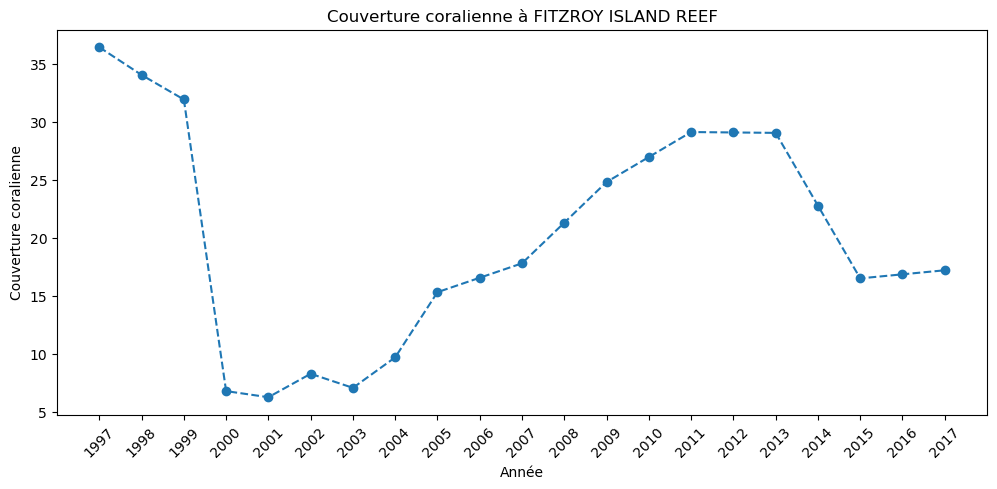

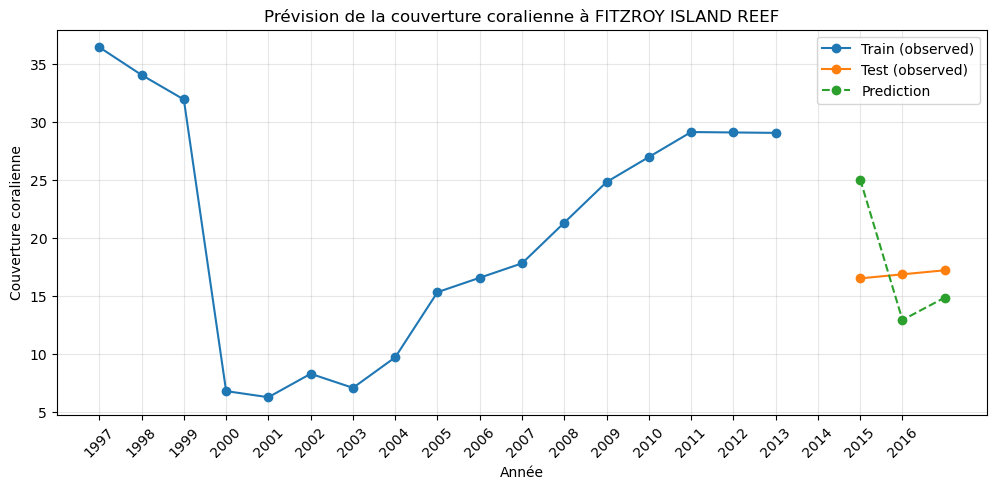

In [39]:
train_reef = reef_yearly_train_viz[reef_yearly_train['REEF_NAME_FITZROY ISLAND REEF'] == 1]
test_reef  = reef_yearly_test_viz[reef_yearly_test['REEF_NAME_FITZROY ISLAND REEF'] == 1]

test_reef_plot = test_reef.copy()
test_reef_plot['REPORT_YEAR_target'] = test_reef_plot['REPORT_YEAR'] + 1

plt.figure(figsize = (12, 5))
plt.plot(reef_yearly.loc[reef_yearly['REEF_NAME'] == 'FITZROY ISLAND REEF']['REPORT_YEAR'], 
         reef_yearly.loc[reef_yearly['REEF_NAME'] == 'FITZROY ISLAND REEF']['HC_b'],  linestyle='--', marker='o') 
plt.xlabel("Année")
plt.ylabel("Couverture coralienne")
plt.title("Couverture coralienne à FITZROY ISLAND REEF")
plt.xticks(sorted(set(reef_yearly['REPORT_YEAR'])), rotation=45)


plt.figure(figsize=(12,5))

plt.plot(train_reef['REPORT_YEAR'], train_reef['HC_b'],
         label='Train (observed)', marker='o')

plt.plot(test_reef_plot['REPORT_YEAR_target'], y_test.loc[test_reef.index],
         label='Test (observed)', marker='o')

plt.plot(test_reef_plot['REPORT_YEAR_target'], test_reef_plot['prediction'],
         label='Prediction', linestyle='--', marker='o')

plt.xlabel("Année")
plt.ylabel("Couverture coralienne")
plt.title("Prévision de la couverture coralienne à FITZROY ISLAND REEF")

years = list(train_reef['REPORT_YEAR']) + list(test_reef['REPORT_YEAR'])
plt.xticks(sorted(set(years)), rotation=45)

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


> Passons maintenant à l’interprétabilité avec **SHAP**.
>
> Initialisons un `explainer` et utilisons-le pour calculer les valeurs de Shapley avec SHAP.

In [40]:
import shap

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(reef_yearly_test)

print(f"Shape des SHAP values : {shap_values.shape}")
print(f"Valeur de base du modèle (expected value) : {explainer.expected_value}")
print(f"Prédiction du modèle pour la première observation : {reef_yearly_test_viz['prediction'].iloc[0]}")
print(f"Somme des SHAP values + expected value : {(explainer.expected_value + shap_values[0, :].sum())}")

df_shap_values = pd.DataFrame(shap_values, columns = reef_yearly_test.columns)
df_shap_values.head()

Shape des SHAP values : (138, 68)
Valeur de base du modèle (expected value) : [28.02500106]
Prédiction du modèle pour la première observation : 42.01128733333341
Somme des SHAP values + expected value : [42.01128733]


,REPORT_YEAR,HC_1_b,HC_2_b,HC_trend_2yrs,HC_increasing_2yrs,HC_1_b_sd,HC_2_b_sd,protected_area,REEF_NAME_19131S,REEF_NAME_19138S,REEF_NAME_20104S,REEF_NAME_21529S,REEF_NAME_AGINCOURT REEFS (NO 1),REEF_NAME_BORDER ISLAND REEF (NO 1),REEF_NAME_BROOMFIELD REEF,REEF_NAME_CARTER REEF,REEF_NAME_CHICKEN REEF,REEF_NAME_CHINAMAN REEF(22102),REEF_NAME_DAVIES REEF,REEF_NAME_DIP REEF,REEF_NAME_EAST CAY REEF,REEF_NAME_FITZROY ISLAND REEF,REEF_NAME_GANNETT CAY REEF,REEF_NAME_GREEN ISLAND REEF,REEF_NAME_HASTINGS REEF,REEF_NAME_HAVANNAH REEF,REEF_NAME_HAYMAN ISLAND REEF,REEF_NAME_HORSESHOE,REEF_NAME_HYDE REEF,REEF_NAME_JOHN BREWER REEF,REEF_NAME_LADY MUSGRAVE REEF,REEF_NAME_LANGFORD-BIRD REEF,REEF_NAME_LINNET REEF,REEF_NAME_LIZARD ISLAND,REEF_NAME_LOW ISLANDS REEF,REEF_NAME_MACGILLIVRAY REEF,REEF_NAME_MACKAY REEF,REEF_NAME_MARTIN REEF(14123),REEF_NAME_MICHAELMAS REEF,REEF_NAME_MYRMIDON REEF,REEF_NAME_NO NAME REEF,REEF_NAME_NORTH DIRECTION REEF,REEF_NAME_ONE TREE REEF,REEF_NAME_OPAL (2),REEF_NAME_PANDORA REEF,REEF_NAME_REBE REEF,REEF_NAME_RIB REEF,REEF_NAME_SLATE REEF,REEF_NAME_SNAKE (22088),REEF_NAME_ST CRISPIN REEF,REEF_NAME_THETFORD REEF,REEF_NAME_TURNER REEF,REEF_NAME_WRECK ISLAND REEF,REEF_NAME_YONGE REEF,CLUSTER_CL1,CLUSTER_CL2,CLUSTER_CL3,CLUSTER_CL4,SHELF_I,SHELF_M,SHELF_O,DISTURBANCE_B,DISTURBANCE_C,DISTURBANCE_D,DISTURBANCE_M,DISTURBANCE_N,DISTURBANCE_S,DISTURBANCE_U
0,-1.986445,13.862626,-0.475894,-0.000901,0.971923,-0.045424,-0.882335,0.208495,0.340119,0.001546,0.003891,0.069747,-0.006517,-0.000797,-0.004794,-0.009061,0.002202,-0.007775,0.009278,0.006192,0.004556,0.022468,0.036740,0.003020,0.000747,0.002290,-0.003301,-0.045559,0.005843,0.004263,-0.059536,0.000385,-0.014159,0.002465,0.000485,0.000654,0.005120,0.000606,0.004206,0.003616,-0.004899,-0.002775,-0.022396,0.000172,-0.001337,0.002735,0.019223,0.000571,-0.046256,0.002686,-0.002341,0.001382,0.003957,0.019223,0.000390,0.206253,0.094237,-0.019703,-0.058845,0.036768,0.000098,0.001036,0.058364,0.015946,0.002781,1.610105,0.045040,-0.007112
1,-1.922306,14.583055,-0.740536,-0.719225,-0.049532,0.354055,0.095529,0.209210,0.423777,-0.002809,0.023628,0.051430,-0.005440,-0.001037,-0.011168,-0.002491,0.002861,-0.005640,0.010819,0.006263,0.003952,0.024470,0.040996,0.002897,0.001106,0.007576,0.001810,-0.042935,0.005892,0.004410,-0.058834,-0.000186,-0.017081,0.002975,-0.000045,0.000484,0.006163,0.001159,0.004568,0.003910,-0.004831,-0.002019,-0.014364,0.000176,-0.002572,0.003093,0.019303,0.000208,-0.057608,0.002720,-0.002578,0.001323,0.012448,0.011653,-0.000551,0.234464,0.096619,-0.024388,-0.064301,0.007794,0.060462,0.001265,0.067065,0.028986,0.001925,1.219954,0.047652,-0.007649
2,-1.871145,13.931768,-0.714621,-0.684329,-0.079458,0.091214,-0.954580,0.255862,0.441537,-0.007635,0.009055,0.090766,-0.005943,-0.001007,-0.009244,-0.003593,0.002934,-0.005490,0.010916,0.006174,0.004353,0.025883,0.040801,0.002938,0.000962,0.002389,-0.003408,-0.041775,0.005898,0.004324,-0.060456,-0.000004,-0.025419,0.002913,-0.000101,0.000588,0.005393,0.000725,0.004594,0.003746,-0.004625,-0.002003,-0.011941,0.000137,-0.001815,0.002895,0.019028,0.000339,-0.050663,0.002598,-0.002518,0.001325,0.014415,0.013897,-0.001176,0.266523,0.097422,-0.018112,-0.055075,0.019942,0.051865,0.000917,0.067676,0.018205,0.000379,1.255679,0.044726,-0.007977
3,-1.289353,5.655209,0.011114,0.614177,0.403567,-0.302840,0.210307,0.140742,-0.045389,0.414573,-0.040843,0.034939,0.001687,-0.002528,0.012108,-0.025243,-0.001097,-0.006706,0.050534,0.006486,0.003271,0.086791,0.113310,0.002967,0.001341,0.011100,0.001482,-0.029535,0.005866,0.005813,-0.031386,0.000315,-0.006382,0.002811,0.000069,0.000791,0.015200,0.004165,0.004432,0.031177,0.002980,0.015167,-0.015867,0.000134,-0.002165,0.002823,0.008285,-0.000528,-0.036946,0.013056,0.000066,0.022738,0.049686,0.005372,0.032164,0.561403,0.152490,-0.060910,0.023763,0.084738,-0.000023,-0.002249,0.132679,0.003635,-0.003137,1.849357,0.030545,0.000731
4,-1.764345,7.694215,-0.612716,0.335017,0.573105,-0.370875,-0.06

> Affichons l’interprétabilité globale de notre modèle.

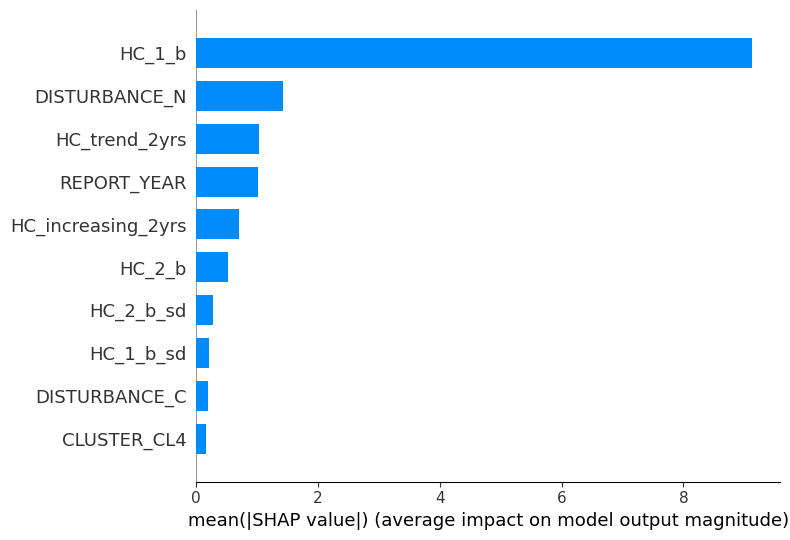

In [41]:
shap.summary_plot(shap_values, reef_yearly_test, plot_type="bar", max_display= 10)

> Utilisons `summary_plot` pour obtenir, dans un seul graphique, une vision à la fois globale et locale de l’interprétabilité.

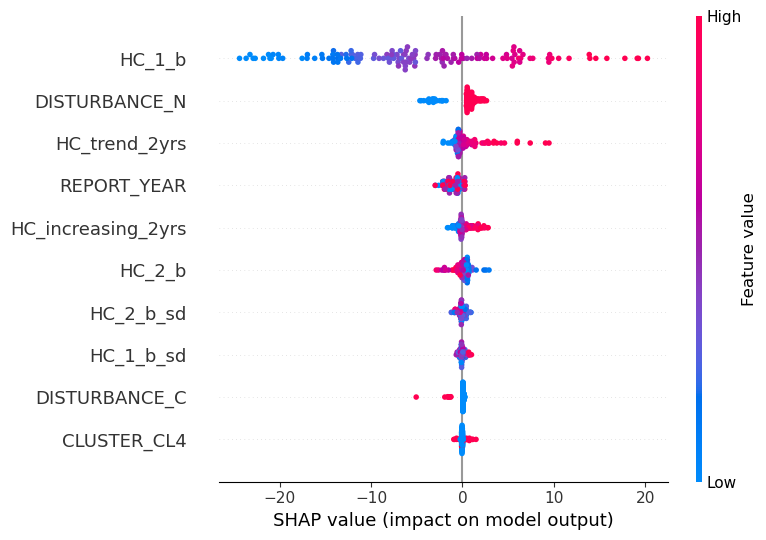

In [42]:
shap.summary_plot(shap_values, reef_yearly_test, max_display= 10)

> Utilisons un graphique de dépendance partielle pour visualiser comment les valeurs de Shapley évoluent en fonction des valeurs de la variable `HC_trend_2yrs`

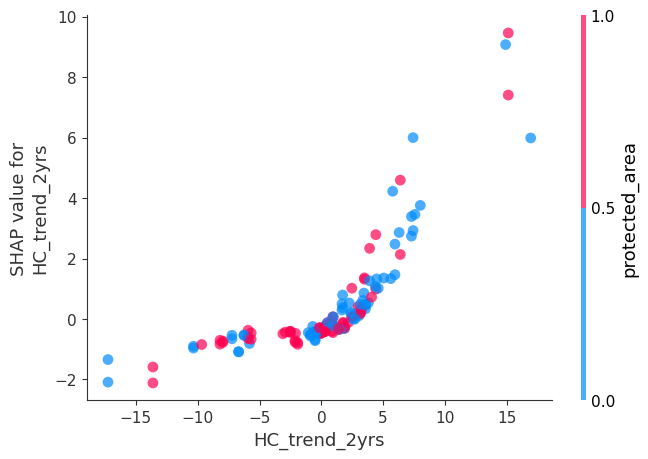

In [43]:
shap.dependence_plot(
    ind='HC_trend_2yrs',         
    shap_values=shap_values,   
    features=reef_yearly_test,  
    interaction_index='protected_area',  
    alpha=0.7,                 
    dot_size=60
)

> Et terminons avec l’interprétabilité locale pour une seule observation : la dernière année pour `FITZROY ISLAND REEF`.

In [44]:
reef_idx = reef_yearly_test[reef_yearly_test['REEF_NAME_FITZROY ISLAND REEF'] == 1].index

reef_relative_idx = [reef_yearly_test.index.get_loc(i) for i in reef_idx]

shap.initjs()
shap.force_plot(
    explainer.expected_value, 
    shap_values[reef_relative_idx[2], :], 
    reef_yearly_test.loc[reef_idx[2], :]
)

# Conclusion

> Dans ce notebook, nous avons appliqué une approche de machine learning qui nous permet de prédire la couverture corallienne par récif en utilisant à la fois les informations sur la couverture corallienne du récif lui-même et d’autres variables exogènes.
>
> Nous avons parcouru toutes les étapes d’un projet de machine learning :
> 
- du traitement des valeurs manquantes
- à la création de nouvelles variables intégrant des informations historiques par récif,
- jusqu’à l’entraînement du modèle,
- son évaluation
- et l’analyse de son interprétabilité.